# Taller B4-T1 — Diseño de Redes Confiables

**Componentes del equipo:**

- Albert Martin
- Josep Pérez Segura
- Rodolfo Villena

**Práctica:** Diseño de redes confiables para clasificación de riesgo de crédito.

**Bloques implementados en esta versión:**

1. Arquitectura customizada mediante una capa financiera `DebtBurdenLayer`.
2. Aprendizaje justo mediante funciones de pérdida FAIR que penalizan la dependencia entre las predicciones y la variable sensible `CODE_GENDER`.

El objetivo de este notebook es construir, entrenar y auditar un modelo de clasificación binaria para riesgo de crédito, incorporando restricciones financieras explícitas y una primera estrategia de reducción de dependencia estadística respecto al género.

Vamos a trabajar con el dataset `application_train.csv` de Home Credit Default Risk y construiremos un modelo binario para predecir `TARGET`:

- `TARGET = 1`: cliente con dificultades de pago.
- `TARGET = 0`: cliente sin dificultades de pago.

Este notebook integra los dos primeros bloques de la práctica:

1. una arquitectura customizada basada en ratios financieros calculados por `DebtBurdenLayer`;
2. una extensión de aprendizaje justo mediante funciones de pérdida customizadas que penalizan la dependencia estadística entre las predicciones y `CODE_GENDER`.

La capa `DebtBurdenLayer` calcula dentro del modelo dos indicadores financieros interpretables:

- cuota anual sobre ingresos: `AMT_ANNUITY / AMT_INCOME_TOTAL`;
- crédito total sobre ingresos: `AMT_CREDIT / AMT_INCOME_TOTAL`.

Estos ratios se calculan con variables monetarias en bruto, no con variables escaladas, para conservar su significado económico.

In [1]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.utils.class_weight import compute_class_weight

RANDOM_STATE = 42
os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

DATA_PATH_CANDIDATES = [Path("data") / "application_train.csv", Path("application_train.csv")]
DATA_PATH = next((path for path in DATA_PATH_CANDIDATES if path.exists()), DATA_PATH_CANDIDATES[0])
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

## Por qué no usamos `CODE_GENDER` como entrada

`CODE_GENDER` se trata como **variable sensible**. La guardamos aparte porque será necesaria para auditar diferencias entre grupos y, más adelante, para diseñar o evaluar restricciones de justicia.

En esta primera arquitectura no se incluye como entrada directa del modelo. De este modo evitamos que la red utilice explícitamente el género para optimizar la predicción. Esto no garantiza justicia por sí solo, porque otras variables pueden contener información correlacionada con el género, pero deja preparada una separación clara entre:

- variables predictoras usadas por la red;
- variable sensible usada para auditoría y futuras pérdidas FAIR.

## Carga y preprocesado de datos

La función `load_home_credit_data` realiza un preprocesado cuidadoso y evita fugas de información entre entrenamiento, validación y test:

- lee únicamente las columnas necesarias para este punto;
- elimina los casos `CODE_GENDER == "XNA"`;
- convierte `CODE_GENDER` a una variable binaria sensible (`M -> 0`, `F -> 1`);
- transforma `DAYS_BIRTH` en edad positiva en años;
- separa `y`, `s` y las variables de entrada del modelo;
- crea dos ramas de entrada: una escalada y otra financiera en bruto;
- separa explícitamente `train`, `validation` y `test`;
- ajusta imputador y escalador solo con `train`;
- aplica esas transformaciones a `validation` y `test` sin recalcular parámetros.

In [2]:
def load_home_credit_data(file_path):
    """Carga y prepara los datos de Home Credit para la arquitectura customizada.

    La función devuelve tres subconjuntos separados: train, validation y test.
    Cada subconjunto contiene:
    1. variables predictoras imputadas y escaladas;
    2. variables financieras imputadas en bruto, sin escalar;
    3. etiqueta binaria `TARGET` en formato float32 para Keras;
    4. variable sensible `CODE_GENDER` conservada aparte para auditoría.

    La rama financiera se mantiene en escala monetaria real porque los ratios de
    `DebtBurdenLayer` deben calcularse sobre importes originales o imputados, no
    sobre z-scores.
    """

    selected_cols = [
        "TARGET",
        "CODE_GENDER",
        "AMT_INCOME_TOTAL",
        "AMT_CREDIT",
        "AMT_ANNUITY",
        "DAYS_BIRTH",
        "EXT_SOURCE_1",
        "EXT_SOURCE_2",
        "EXT_SOURCE_3",
    ]

    df = pd.read_csv(file_path, usecols=selected_cols)
    df = df.loc[df["CODE_GENDER"] != "XNA"].copy()

    # Flags de missingness calculados antes de imputar. No entran todavía como
    # inputs del modelo, pero quedan disponibles para incertidumbre y auditoría.
    ext_source_cols = ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]
    missing_flag_cols = [f"{col}_missing" for col in ext_source_cols]
    ext_source_missing_flags = df[ext_source_cols].isna().astype("int32")
    ext_source_missing_flags.columns = missing_flag_cols

    ext_source_missingness_summary = pd.DataFrame(
        {
            "variable": ext_source_cols,
            "missing_count": df[ext_source_cols].isna().sum().to_numpy(),
            "missing_rate": df[ext_source_cols].isna().mean().to_numpy(),
        }
    )

    # Variable sensible codificada y conservada fuera del input del modelo.
    df["CODE_GENDER"] = df["CODE_GENDER"].map({"M": 0, "F": 1}).astype(int)

    # Edad positiva en años. La columna original se elimina para evitar duplicar
    # la misma información con dos escalas distintas.
    df["AGE_YEARS"] = np.abs(df["DAYS_BIRTH"]) / 365.25
    df = df.drop(columns=["DAYS_BIRTH"])

    scaled_features = [
        "AMT_INCOME_TOTAL",
        "AMT_CREDIT",
        "AMT_ANNUITY",
        "AGE_YEARS",
        "EXT_SOURCE_1",
        "EXT_SOURCE_2",
        "EXT_SOURCE_3",
    ]
    financial_features = ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY"]

    X = df[scaled_features].copy()
    y = df["TARGET"].astype(int)
    s = df["CODE_GENDER"].astype(int)

    # Primer split: separamos test y no lo tocamos durante entrenamiento ni
    # selección de hiperparámetros.
    (
        X_trainval,
        X_test,
        missing_trainval,
        missing_test,
        y_trainval,
        y_test,
        s_trainval,
        s_test,
    ) = train_test_split(
        X,
        ext_source_missing_flags,
        y,
        s,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=y,
    )

    # Segundo split: separamos validation desde trainval. El reparto final queda
    # aproximadamente en 64 % train, 16 % validation y 20 % test.
    (
        X_train,
        X_val,
        missing_train,
        missing_val,
        y_train,
        y_val,
        s_train,
        s_val,
    ) = train_test_split(
        X_trainval,
        missing_trainval,
        y_trainval,
        s_trainval,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=y_trainval,
    )

    # Imputación ajustada solo con train. Validation y test se transforman con el
    # mismo imputador para evitar data leakage.
    imputer = SimpleImputer(strategy="median")
    X_train_imputed = pd.DataFrame(
        imputer.fit_transform(X_train),
        columns=X_train.columns,
        index=X_train.index,
    )
    X_val_imputed = pd.DataFrame(
        imputer.transform(X_val),
        columns=X_val.columns,
        index=X_val.index,
    )
    X_test_imputed = pd.DataFrame(
        imputer.transform(X_test),
        columns=X_test.columns,
        index=X_test.index,
    )

    # Rama financiera: datos imputados, pero no escalados. Así los ratios internos
    # siguen teniendo interpretación económica.
    X_train_financial_raw = X_train_imputed[financial_features].astype("float32")
    X_val_financial_raw = X_val_imputed[financial_features].astype("float32")
    X_test_financial_raw = X_test_imputed[financial_features].astype("float32")

    # Rama principal: escalado ajustado solo con train.
    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(
        scaler.fit_transform(X_train_imputed[scaled_features]),
        columns=scaled_features,
        index=X_train_imputed.index,
    )
    X_val_scaled = pd.DataFrame(
        scaler.transform(X_val_imputed[scaled_features]),
        columns=scaled_features,
        index=X_val_imputed.index,
    )
    X_test_scaled = pd.DataFrame(
        scaler.transform(X_test_imputed[scaled_features]),
        columns=scaled_features,
        index=X_test_imputed.index,
    )

    X_train_scaled_np = X_train_scaled.astype("float32")
    X_val_scaled_np = X_val_scaled.astype("float32")
    X_test_scaled_np = X_test_scaled.astype("float32")

    y_train_np = y_train.astype("float32").values
    y_val_np = y_val.astype("float32").values
    y_test_np = y_test.astype("float32").values

    preprocessor = {
        "feature_cols": scaled_features,
        "financial_cols": financial_features,
        "imputer": imputer,
        "medians": pd.Series(imputer.statistics_, index=scaled_features),
        "scaler": scaler,
        "missing_flag_cols": missing_flag_cols,
        "ext_source_missing_train": missing_train.reset_index(drop=True),
        "ext_source_missing_val": missing_val.reset_index(drop=True),
        "ext_source_missing_test": missing_test.reset_index(drop=True),
        "ext_source_missingness_summary": ext_source_missingness_summary,
    }

    return (
        X_train_scaled_np,
        X_train_financial_raw,
        y_train_np,
        s_train,
    ), (
        X_val_scaled_np,
        X_val_financial_raw,
        y_val_np,
        s_val,
    ), (
        X_test_scaled_np,
        X_test_financial_raw,
        y_test_np,
        s_test,
    ), preprocessor

## Split explícito train / validation / test

En esta versión sustituimos la partición automática de validación por un conjunto de validación explícito. Esto permite conservar también la variable sensible `CODE_GENDER` en validación (`s_val`), lo cual será necesario para la siguiente fase de la práctica: medir y penalizar la dependencia entre las predicciones del modelo y la variable sensible.

El conjunto de test se mantiene separado y no se usa durante el entrenamiento ni durante la selección de hiperparámetros.

Antes de entrenar el modelo conviene comprobar que las ramas tienen las formas esperadas y que las distribuciones principales se conservan tras el split.

In [3]:
(
    X_train_scaled_np,
    X_train_financial_raw,
    y_train_np,
    s_train,
), (
    X_val_scaled_np,
    X_val_financial_raw,
    y_val_np,
    s_val,
), (
    X_test_scaled_np,
    X_test_financial_raw,
    y_test_np,
    s_test,
), preprocessor = load_home_credit_data(DATA_PATH)

print("Shape de X_train_scaled_np:", X_train_scaled_np.shape)
print("Shape de X_val_scaled_np:", X_val_scaled_np.shape)
print("Shape de X_test_scaled_np:", X_test_scaled_np.shape)
print("Shape de X_train_financial_raw:", X_train_financial_raw.shape)
print("Shape de X_val_financial_raw:", X_val_financial_raw.shape)
print("Shape de X_test_financial_raw:", X_test_financial_raw.shape)
print("Shape de y_train_np:", y_train_np.shape)
print("Shape de y_val_np:", y_val_np.shape)
print("Shape de y_test_np:", y_test_np.shape)

print("\ns_train shape:", s_train.shape)
print("s_val shape:", s_val.shape)
print("s_test shape:", s_test.shape)

print("\nColumnas de la rama escalada:")
print(preprocessor["feature_cols"])

print("\nColumnas de la rama financiera en bruto:")
print(preprocessor["financial_cols"])

print("\nFlags de missingness preparados para análisis posterior:")
print(preprocessor["missing_flag_cols"])

missingness_path = OUTPUT_DIR / "ext_source_missingness_summary.csv"
preprocessor["ext_source_missingness_summary"].to_csv(missingness_path, index=False)
print(f"\nResumen de missingness guardado en: {missingness_path}")
display(preprocessor["ext_source_missingness_summary"])

Shape de X_train_scaled_np: (196804, 7)
Shape de X_val_scaled_np: (49201, 7)
Shape de X_test_scaled_np: (61502, 7)
Shape de X_train_financial_raw: (196804, 3)
Shape de X_val_financial_raw: (49201, 3)
Shape de X_test_financial_raw: (61502, 3)
Shape de y_train_np: (196804,)
Shape de y_val_np: (49201,)
Shape de y_test_np: (61502,)

s_train shape: (196804,)
s_val shape: (49201,)
s_test shape: (61502,)

Columnas de la rama escalada:
['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AGE_YEARS', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']

Columnas de la rama financiera en bruto:
['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY']

Flags de missingness preparados para análisis posterior:
['EXT_SOURCE_1_missing', 'EXT_SOURCE_2_missing', 'EXT_SOURCE_3_missing']

Resumen de missingness guardado en: outputs/ext_source_missingness_summary.csv


,variable,missing_count,missing_rate
0,EXT_SOURCE_1,173376,0.563812
1,EXT_SOURCE_2,660,0.002146
2,EXT_SOURCE_3,60965,0.198256


In [4]:
# Distribución de TARGET en train, validation y test. normalize=True muestra
# proporciones, útil porque el problema está desbalanceado hacia la clase 0.
print("Distribución de TARGET en train:")
print(pd.Series(y_train_np, name="TARGET").value_counts(normalize=True).sort_index())

print("\nDistribución de TARGET en validation:")
print(pd.Series(y_val_np, name="TARGET").value_counts(normalize=True).sort_index())

print("\nDistribución de TARGET en test:")
print(pd.Series(y_test_np, name="TARGET").value_counts(normalize=True).sort_index())

# Distribución de la variable sensible. Esta información no se usa como input
# del modelo, pero se conserva para los siguientes puntos de justicia.
print("\nDistribución de CODE_GENDER en train (0=M, 1=F):")
print(s_train.value_counts(normalize=True).sort_index())

print("\nDistribución de CODE_GENDER en validation (0=M, 1=F):")
print(s_val.value_counts(normalize=True).sort_index())

print("\nDistribución de CODE_GENDER en test (0=M, 1=F):")
print(s_test.value_counts(normalize=True).sort_index())

Distribución de TARGET en train:
TARGET
0.0    0.91927
1.0    0.08073
Name: proportion, dtype: float64

Distribución de TARGET en validation:
TARGET
0.0    0.91927
1.0    0.08073
Name: proportion, dtype: float64

Distribución de TARGET en test:
TARGET
0.0    0.919271
1.0    0.080729
Name: proportion, dtype: float64

Distribución de CODE_GENDER en train (0=M, 1=F):
CODE_GENDER
0    0.341939
1    0.658061
Name: proportion, dtype: float64

Distribución de CODE_GENDER en validation (0=M, 1=F):
CODE_GENDER
0    0.341578
1    0.658422
Name: proportion, dtype: float64

Distribución de CODE_GENDER en test (0=M, 1=F):
CODE_GENDER
0    0.340769
1    0.659231
Name: proportion, dtype: float64


### Interpretación del desbalance de clases

La variable objetivo está fuertemente desbalanceada. Aproximadamente el 92 % de los clientes pertenecen a la clase `TARGET = 0` y solo alrededor del 8 % pertenecen a la clase `TARGET = 1`.

Esto implica que la métrica `accuracy` debe interpretarse con cautela. Un modelo trivial que predijera siempre “buen pagador” obtendría una accuracy muy alta, pero no detectaría ningún cliente con dificultades de pago.

Por este motivo, en este problema son especialmente relevantes métricas como AUC, recall de la clase minoritaria, precision de la clase minoritaria y balanced accuracy.

In [5]:
# Primeras filas de la rama financiera en bruto. Deben verse como importes
# monetarios originales, no como variables centradas alrededor de cero.
X_train_financial_raw.head(10)

,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY
1228,90000.0,203760.0,11826.0
162360,67500.0,180000.0,9000.0
68610,315000.0,1125000.0,44019.0
122818,225000.0,156384.0,16155.0
274639,135000.0,573628.5,24435.0
154292,211500.0,729567.0,27166.5
290325,180000.0,113076.0,5773.5
176690,112500.0,381528.0,22032.0
156479,67500.0,343800.0,16155.0
212749,121500.0,942300.0,30528.0


## Por qué calculamos ratios financieros en una capa customizada

Una red densa estándar puede aprender interacciones entre variables, pero no sabe de partida que ciertos cocientes financieros son especialmente relevantes.

La capa customizada introduce conocimiento previo del dominio:

- una cuota anual alta respecto a ingresos puede indicar mayor presión financiera;
- un crédito alto respecto a ingresos puede indicar mayor exposición al endeudamiento.

Al calcular estos ratios dentro del grafo de TensorFlow, la transformación queda integrada en el modelo, aparece en `model.summary()` y puede serializarse junto con la arquitectura.

## Flags de missingness para `EXT_SOURCE`

Las variables `EXT_SOURCE_1`, `EXT_SOURCE_2` y `EXT_SOURCE_3` tienen valores ausentes. En este punto los valores se imputan con medianas calculadas solo en train, pero además conservamos tres indicadores auxiliares:

- `EXT_SOURCE_1_missing`;
- `EXT_SOURCE_2_missing`;
- `EXT_SOURCE_3_missing`.

Estos flags valen 1 si el dato original estaba ausente y 0 si estaba informado. No se usan todavía como entrada de la arquitectura principal, pero quedan preparados para el análisis posterior de incertidumbre. El resumen de missingness se guarda en `outputs/ext_source_missingness_summary.csv`.

## Por qué se usa `tanh` como saturación

Los ratios financieros pueden tomar valores extremos cuando los ingresos son bajos o cuando el crédito es muy alto. Si se pasan directamente a la red, esos valores pueden dominar el entrenamiento.

Usamos `tanh` porque es una saturación suave y diferenciable:

- mantiene el entrenamiento compatible con backpropagation;
- comprime valores extremos;
- conserva una señal ordenada: ratios más altos producen salidas saturadas más altas;
- reduce el impacto de outliers sin aplicar cortes bruscos.

### Interpretación de la capa `DebtBurdenLayer`

La capa customizada introduce conocimiento financiero dentro de la arquitectura neuronal.

En lugar de dejar que la red aprenda desde cero todas las relaciones entre ingresos, crédito y anualidad, calculamos explícitamente dos ratios interpretables:

- cuota anual sobre ingresos;
- crédito total sobre ingresos.

Después aplicamos una saturación suave mediante `tanh`. Esta saturación evita que ratios extremos dominen el entrenamiento, pero conserva el orden económico de la señal: ratios más altos siguen generando valores más altos.

La capa no tiene parámetros entrenables. Su función es imponer una transformación financiera razonable antes de pasar la información a las capas densas.

In [6]:
class DebtBurdenLayer(tf.keras.layers.Layer):
    """Capa customizada para calcular ratios de endeudamiento saturados.

    La capa recibe tres columnas en este orden:
    [AMT_INCOME_TOTAL, AMT_CREDIT, AMT_ANNUITY]

    Devuelve dos columnas:
    1. `annuity_ratio_sat`: cuota anual sobre ingresos, saturada con tanh.
    2. `credit_ratio_sat`: crédito total sobre ingresos, saturado con tanh.
    """

    def __init__(self, annuity_tau=0.5, credit_tau=5.0, epsilon=1e-6, **kwargs):
        super().__init__(**kwargs)
        self.annuity_tau = annuity_tau
        self.credit_tau = credit_tau
        self.epsilon = epsilon

    def call(self, inputs):
        # Separación explícita de columnas. Usamos rangos como 0:1 para mantener
        # tensores bidimensionales de shape (batch_size, 1), lo que facilita la
        # concatenación posterior.
        income = inputs[:, 0:1]
        credit = inputs[:, 1:2]
        annuity = inputs[:, 2:3]

        # Ratios financieros sobre variables monetarias originales. epsilon evita
        # divisiones por cero si apareciera algún ingreso nulo.
        annuity_income_ratio = annuity / (income + self.epsilon)
        credit_income_ratio = credit / (income + self.epsilon)

        # Saturación suave. Los parámetros tau controlan la escala a partir de la
        # cual cada ratio empieza a acercarse a 1.
        annuity_ratio_sat = tf.math.tanh(annuity_income_ratio / self.annuity_tau)
        credit_ratio_sat = tf.math.tanh(credit_income_ratio / self.credit_tau)

        # El resultado final tiene dos columnas y puede concatenarse con la rama
        # principal de variables escaladas.
        return tf.concat([annuity_ratio_sat, credit_ratio_sat], axis=1)

    def get_config(self):
        # Permite guardar y recargar modelos que incluyan esta capa customizada.
        config = super().get_config()
        config.update(
            {
                "annuity_tau": self.annuity_tau,
                "credit_tau": self.credit_tau,
                "epsilon": self.epsilon,
            }
        )
        return config

## Comprobación de la capa customizada

Probamos `DebtBurdenLayer` sobre cinco ejemplos reales de la rama financiera. La salida debe tener dos columnas y valores aproximadamente entre 0 y 1, porque los importes son positivos y `tanh` satura por arriba.

In [7]:
# Instanciamos la capa de forma aislada para verificar su comportamiento antes
# de integrarla en el modelo funcional.
debt_layer_check = DebtBurdenLayer(name="debt_burden_layer_check")
ratio_examples = debt_layer_check(X_train_financial_raw.iloc[:5].to_numpy()).numpy()

ratio_check_df = pd.DataFrame(
    ratio_examples,
    columns=["annuity_ratio_sat", "credit_ratio_sat"],
)

print("Shape de la salida de DebtBurdenLayer:", ratio_examples.shape)
print("\nPrimeros ratios saturados:")
display(ratio_check_df)

print("\nMínimos por columna:")
print(ratio_check_df.min())

print("\nMáximos por columna:")
print(ratio_check_df.max())

Shape de la salida de DebtBurdenLayer: (5, 2)

Primeros ratios saturados:


,annuity_ratio_sat,credit_ratio_sat
0,0.256913,0.424198
1,0.260520,0.487925
2,0.272429,0.613357
3,0.142621,0.138119
4,0.346974,0.690975



Mínimos por columna:
annuity_ratio_sat    0.142621
credit_ratio_sat     0.138119
dtype: float32

Máximos por columna:
annuity_ratio_sat    0.346974
credit_ratio_sat     0.690975
dtype: float32


## Modelo funcional con dos entradas

La red tiene dos ramas de entrada:

- `scaled_features`: siete variables imputadas y escaladas;
- `financial_raw`: tres variables monetarias imputadas sin escalar.

La capa `DebtBurdenLayer` transforma la rama financiera en dos ratios saturados. Después concatenamos esos dos ratios con las siete variables escaladas y entrenamos capas densas para la clasificación binaria.

In [8]:
def build_custom_debt_model(n_scaled_features):
    """Construye el modelo Keras funcional con la capa DebtBurdenLayer."""

    # Entrada principal: variables numéricas ya imputadas y estandarizadas.
    scaled_input = keras.Input(
        shape=(n_scaled_features,),
        name="scaled_features",
    )

    # Entrada financiera: importes originales imputados, sin escalar. Esta rama
    # existe exclusivamente para calcular ratios interpretables dentro del modelo.
    financial_raw_input = keras.Input(
        shape=(3,),
        name="financial_raw",
    )

    # Capa customizada solicitada en la práctica. Debe aparecer en model.summary().
    ratios = DebtBurdenLayer(name="debt_burden_layer")(financial_raw_input)

    # Unimos las variables escaladas con los ratios financieros calculados por
    # la red. El tensor resultante tiene 7 + 2 = 9 variables.
    x = layers.Concatenate(name="concat_scaled_and_custom_ratios")(
        [scaled_input, ratios]
    )

    # Bloque denso sencillo. BatchNormalization ayuda a estabilizar activaciones
    # intermedias; Dropout reduce sobreajuste en una tabla con muchas filas.
    x = layers.Dense(64, activation="relu", name="dense_64")(x)
    x = layers.BatchNormalization(name="batch_norm_64")(x)
    x = layers.Dropout(0.25, name="dropout_025")(x)

    x = layers.Dense(32, activation="relu", name="dense_32")(x)
    x = layers.Dropout(0.15, name="dropout_015")(x)

    # Salida binaria: probabilidad estimada de TARGET = 1.
    output = layers.Dense(1, activation="sigmoid", name="default_probability")(x)

    model = keras.Model(
        inputs=[scaled_input, financial_raw_input],
        outputs=output,
        name="home_credit_custom_debt_model",
    )

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.AUC(name="auc"),
        ],
    )

    return model


model = build_custom_debt_model(n_scaled_features=X_train_scaled_np.shape[1])
model.summary()

Model: "home_credit_custom_debt_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ financial_raw       │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ scaled_features     │ (None, 7)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ debt_burden_layer   │ (None, 2)         │          0 │ financial_raw[0]… │
│ (DebtBurdenLayer)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_scaled_and_… │ (None, 9)         │          0 │ scaled_features[… │
│ (Concatenate)       │                   │            │ debt_burden_laye… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_64 (Dense)    │ (None, 64)        │        640 │ concat_scaled_an… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_norm_64       │ (None, 64)        │        256 │ dense_64[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_025         │ (None, 64)        │          0 │ batch_norm_64[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_32 (Dense)    │ (None, 32)        │      2,080 │ dropout_025[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_015         │ (None, 32)        │          0 │ dense_32[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ default_probability │ (None, 1)         │         33 │ dropout_015[0][0] │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 128 (512.00 B)

## Entrenamiento

`TARGET` está desbalanceada: hay muchos más buenos pagadores que clientes con dificultades. Para compensarlo, calculamos `class_weight` con sklearn y lo pasamos a `model.fit`.

También usamos dos callbacks:

- `EarlyStopping`, para recuperar los mejores pesos según `val_auc`;
- `ReduceLROnPlateau`, para reducir la tasa de aprendizaje si `val_auc` deja de mejorar.

In [9]:
# Pesos de clase calculados solo con y_train. El objetivo es que la clase
# minoritaria tenga más peso durante la optimización.
classes = np.unique(y_train_np.astype(int))
class_weights_values = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_np.astype(int),
)

# Conversión explícita a tipos nativos de Python para evitar impresiones como
# np.int64(0) o np.float64(...), y para mantener compatibilidad clara con Keras.
class_weight = {
    int(cls): float(weight)
    for cls, weight in zip(classes, class_weights_values)
}

print("Class weights:", class_weight)

EPOCHS = 100
BATCH_SIZE = 1024

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=15,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc",
        mode="max",
        factor=0.5,
        patience=6,
        min_lr=1e-5,
        verbose=1,
    ),
]

history = model.fit(
    x={
        "scaled_features": X_train_scaled_np,
        "financial_raw": X_train_financial_raw,
    },
    y=y_train_np,
    validation_data=(
        {
            "scaled_features": X_val_scaled_np,
            "financial_raw": X_val_financial_raw,
        },
        y_val_np,
    ),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1,
)

Class weights: {0: 0.5439098808286719, 1: 6.193479355488419}
Epoch 1/100
193/193 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.6388 - auc: 0.6810 - loss: 0.6563 - val_accuracy: 0.6411 - val_auc: 0.7232 - val_loss: 0.6535 - learning_rate: 0.0010
Epoch 2/100
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6545 - auc: 0.7130 - loss: 0.6233 - val_accuracy: 0.6495 - val_auc: 0.7257 - val_loss: 0.6290 - learning_rate: 0.0010
Epoch 3/100
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6578 - auc: 0.7173 - loss: 0.6192 - val_accuracy: 0.6556 - val_auc: 0.7265 - val_loss: 0.6131 - learning_rate: 0.0010
Epoch 4/100
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6569 - auc: 0.7208 - loss: 0.6167 - val_accuracy: 0.6615 - val_auc: 0.7274 - val_loss: 0.6114 - learning_rate: 0.0010
Epoch 5/100
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6612 - auc: 0.7225 - loss: 0.6149 - val_accuracy: 0.6665 - val_auc: 0.7274 - val_loss: 0.6075 - learning_rate: 0.0010
Epoch 6/100
1

## Curvas de entrenamiento

Las curvas permiten comprobar visualmente si el modelo aprende y si aparece sobreajuste. En esta práctica nos interesan especialmente:

- `loss` y `val_loss`, para ver la evolución de la función de coste;
- `auc` y `val_auc`, porque AUC es más informativa que accuracy cuando la clase positiva es minoritaria.

Histórico de entrenamiento guardado en: outputs/training_history_punto1_custom_layer.csv


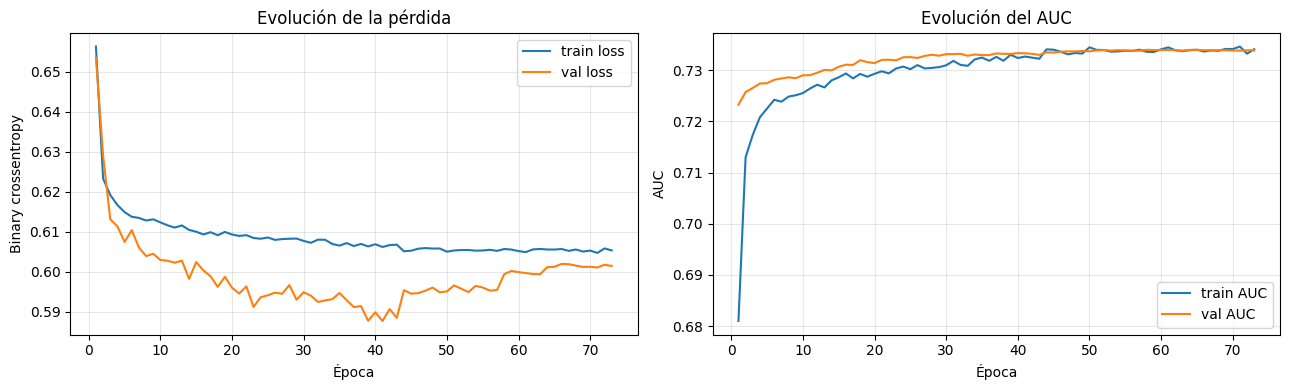

In [10]:
def plot_training_curves(history):
    """Dibuja curvas de loss y AUC para entrenamiento y validación."""

    history_df = pd.DataFrame(history.history)
    history_df.insert(0, "epoch", np.arange(1, len(history_df) + 1))

    history_path = OUTPUT_DIR / "training_history_punto1_custom_layer.csv"
    history_df.to_csv(history_path, index=False)
    print(f"Histórico de entrenamiento guardado en: {history_path}")

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(history_df["epoch"], history_df["loss"], label="train loss")
    axes[0].plot(history_df["epoch"], history_df["val_loss"], label="val loss")
    axes[0].set_title("Evolución de la pérdida")
    axes[0].set_xlabel("Época")
    axes[0].set_ylabel("Binary crossentropy")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(history_df["epoch"], history_df["auc"], label="train AUC")
    axes[1].plot(history_df["epoch"], history_df["val_auc"], label="val AUC")
    axes[1].set_title("Evolución del AUC")
    axes[1].set_xlabel("Época")
    axes[1].set_ylabel("AUC")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_training_curves(history)

## Evaluación en test

Evaluamos sobre el subconjunto de test que no se ha usado para ajustar medianas, escalador ni pesos del modelo. Calculamos métricas básicas de clasificación y guardamos probabilidades para análisis posteriores.

In [11]:
# Evaluación nativa de Keras con las métricas definidas en compile. Se evalúa
# exclusivamente sobre test, que no se ha usado ni para entrenar ni para validar.
test_metrics = model.evaluate(
    x={
        "scaled_features": X_test_scaled_np,
        "financial_raw": X_test_financial_raw,
    },
    y=y_test_np,
    batch_size=1024,
    verbose=0,
    return_dict=True,
)

print("Métricas de test devueltas por Keras:")
print(test_metrics)

# Probabilidades de clase positiva sobre test. El umbral 0.5 se usa solo para
# obtener una predicción binaria sencilla; más adelante podría calibrarse o
# ajustarse por objetivos de justicia/riesgo.
y_test_proba = model.predict(
    {
        "scaled_features": X_test_scaled_np,
        "financial_raw": X_test_financial_raw,
    },
    batch_size=1024,
    verbose=0,
).ravel()

y_test_pred = (y_test_proba >= 0.5).astype(int)

auc_test = roc_auc_score(y_test_np, y_test_proba)
accuracy_test = accuracy_score(y_test_np, y_test_pred)
balanced_accuracy_test = balanced_accuracy_score(y_test_np, y_test_pred)
precision_class_1, recall_class_1, f1_class_1, _ = precision_recall_fscore_support(
    y_test_np,
    y_test_pred,
    labels=[1],
    zero_division=0,
)
conf_matrix = confusion_matrix(y_test_np, y_test_pred, labels=[0, 1])
tn, fp, fn, tp = conf_matrix.ravel()

print(f"AUC test: {auc_test:.4f}")
print(f"Accuracy test con threshold 0.5: {accuracy_test:.4f}")
print(f"Balanced accuracy test con threshold 0.5: {balanced_accuracy_test:.4f}")

print("\nMatriz de confusión:")
print(conf_matrix)

print("\nClassification report:")
print(classification_report(y_test_np, y_test_pred, digits=4, zero_division=0))

metrics_punto1 = pd.DataFrame(
    [
        {
            "test_auc": auc_test,
            "test_accuracy": accuracy_test,
            "balanced_accuracy": balanced_accuracy_test,
            "recall_class_1": recall_class_1[0],
            "precision_class_1": precision_class_1[0],
            "f1_class_1": f1_class_1[0],
            "tn": tn,
            "fp": fp,
            "fn": fn,
            "tp": tp,
        }
    ]
)

metrics_path = OUTPUT_DIR / "metrics_punto1_custom_layer.csv"
metrics_punto1.to_csv(metrics_path, index=False)
print(f"\nTabla final de métricas guardada en: {metrics_path}")
display(metrics_punto1)

Métricas de test devueltas por Keras:
{'accuracy': 0.6825469136238098, 'auc': 0.7368723154067993, 'loss': 0.5959871411323547}
AUC test: 0.7369
Accuracy test con threshold 0.5: 0.6825
Balanced accuracy test con threshold 0.5: 0.6745

Matriz de confusión:
[[38677 17860]
 [ 1664  3301]]

Classification report:
              precision    recall  f1-score   support

         0.0     0.9588    0.6841    0.7985     56537
         1.0     0.1560    0.6649    0.2527      4965

    accuracy                         0.6825     61502
   macro avg     0.5574    0.6745    0.5256     61502
weighted avg     0.8939    0.6825    0.7544     61502


Tabla final de métricas guardada en: outputs/metrics_punto1_custom_layer.csv


,test_auc,test_accuracy,balanced_accuracy,recall_class_1,precision_class_1,f1_class_1,tn,fp,fn,tp
0,0.736928,0.682547,0.674477,0.664854,0.155995,0.252698,38677,17860,1664,3301


### Interpretación de los resultados en test

El modelo obtiene una capacidad razonable para ordenar clientes por riesgo usando un subconjunto reducido de variables. En este contexto, la métrica AUC es más informativa que la accuracy, porque el problema está fuertemente desbalanceado.

La accuracy con umbral 0,5 no debe compararse directamente con la accuracy de un clasificador trivial, ya que el objetivo no es únicamente acertar la clase mayoritaria, sino detectar también clientes con dificultades de pago.

El uso de `class_weight` hace que la clase minoritaria tenga más peso durante el entrenamiento. Como consecuencia, el modelo puede detectar una proporción mayor de clientes con dificultades, aunque a costa de generar más falsos positivos.

Por tanto, este primer modelo debe entenderse como una arquitectura base customizada, no como un modelo final de decisión crediticia. Las siguientes fases deberán añadir auditoría de justicia, comparación con modelo base, ajuste de hiperparámetros e incertidumbre predictiva.

## Primeras predicciones y variable sensible

La siguiente tabla junta predicciones con `s_gender`. Esta variable sensible no ha entrado en el modelo, pero queda disponible para el siguiente punto de la práctica, donde se podrán comparar métricas por grupo y diseñar restricciones de justicia.

In [12]:
prediction_preview = pd.DataFrame(
    {
        "y_real": y_test_np[:10].astype(int),
        "y_proba": y_test_proba[:10],
        "y_pred": y_test_pred[:10],
        "s_gender": s_test.iloc[:10].to_numpy(),
    }
)

prediction_preview

,y_real,y_proba,y_pred,s_gender
0,0,0.331485,0,0
1,0,0.469027,0,0
2,0,0.454245,0,1
3,0,0.366273,0,1
4,0,0.682655,1,1
5,0,0.490223,0,1
6,0,0.506517,1,1
7,0,0.328310,0,1
8,0,0.740837,1,1
9,1,0.226182,0,0


## Transición del punto 1 al punto 2

La primera parte del notebook deja cerrada la arquitectura customizada del punto 1 y mejora el pipeline experimental mediante un split explícito en train, validation y test.

Esta separación permite entrenar el modelo con `train`, seleccionar configuraciones con `validation` y reservar `test` para la evaluación final. Además, se conserva la variable sensible `CODE_GENDER` en `s_train`, `s_val` y `s_test`, sin utilizarla como entrada directa del modelo.

A partir de esta base se desarrolla el punto 2: aprendizaje justo mediante funciones de pérdida customizadas que penalizan la dependencia estadística entre las predicciones del modelo y `CODE_GENDER`.


## Punto 2: Aprendizaje Justo — FAIR Loss

Este apartado implementa el segundo punto de la práctica: diseñar funciones de coste customizadas que combinen el error de clasificación con una penalización por dependencia estadística entre las predicciones del modelo y la variable sensible `CODE_GENDER`.

El objetivo es obtener modelos que reduzcan la dependencia de sus predicciones respecto al género. Para ello se reutiliza la misma arquitectura del punto 1, con `DebtBurdenLayer`, y se entrena con distintos valores del parámetro de penalización λ. Así se genera una familia de modelos con diferentes equilibrios entre rendimiento predictivo, medido con AUC y métricas de clasificación, y justicia medida como menor dependencia estadística entre las predicciones del modelo y la variable sensible `CODE_GENDER`.

Los resultados se resumen en curvas de trade-off y tablas comparativas entre el modelo base y el mejor modelo FAIR seleccionado con validation.

## Punto 2 — Aprendizaje Justo: pérdidas como clases Keras

Se reimplementan las pérdidas de justicia como subclases de `keras.losses.Loss`.
Ventajas frente a closures:
- Serialización con `get_config()` → `model.save()` funciona
- Estado explícito y nombre de clase en `model.summary()`

Se evalúan **2 métricas de fairness** en todos los sweeps y que sean faciles de implementar computacionalmente:
| Métrica | Qué mide |
|---|---|
| **Pearson²** | Correlación lineal ŷ↔s al cuadrado |
| **CKA RBF** | Dependencia no lineal via kernel gaussiano |


### Funciones de evaluación post-entrenamiento


In [13]:
def compute_pearson_sq(y_proba, s_array):
    """Cuadrado de la correlación de Pearson entre y_pred y s."""
    y = np.asarray(y_proba, dtype="float64").reshape(-1)
    s = np.asarray(s_array, dtype="float64").reshape(-1)
    y_c = y - y.mean()
    s_c = s - s.mean()
    numerator = float(np.dot(y_c, s_c)) ** 2
    denominator = float(np.dot(y_c, y_c) * np.dot(s_c, s_c)) + 1e-8
    return numerator / denominator


def compute_cka_rbf_np(y_proba, s_array, gamma=0.5, max_samples=10000):
    """CKA RBF en numpy. Usa gamma=0.5 para alinearse con FairLossCKARBF."""
    y = np.asarray(y_proba, dtype="float64").reshape(-1)
    s = np.asarray(s_array, dtype="float64").reshape(-1)
    if len(y) > max_samples:
        rng = np.random.default_rng(RANDOM_STATE)
        idx = rng.choice(len(y), size=max_samples, replace=False)
        y, s = y[idx], s[idx]

    K = np.exp(-np.square(y[:, None] - y[None, :]) / (2.0 * gamma**2))
    L = np.exp(-np.square(s[:, None] - s[None, :]) / (2.0 * gamma**2))

    def center(matrix):
        return (
            matrix
            - matrix.mean(axis=1, keepdims=True)
            - matrix.mean(axis=0, keepdims=True)
            + matrix.mean()
        )

    K_c = center(K)
    L_c = center(L)
    d2 = (len(y) - 1) ** 2
    hsic_kl = (K_c * L_c).sum() / d2
    hsic_kk = (K_c * K_c).sum() / d2
    hsic_ll = (L_c * L_c).sum() / d2
    return float(max(hsic_kl / (np.sqrt(hsic_kk * hsic_ll) + 1e-8), 0.0))


def evaluate_all(y_true_np, y_proba, s_np, threshold=0.5, cka_gamma=0.5):
    """Calcula métricas predictivas y de dependencia para cualquier split."""
    y_true_np = np.asarray(y_true_np).reshape(-1).astype(int)
    y_proba = np.asarray(y_proba).reshape(-1)
    s_np = np.asarray(s_np).reshape(-1)
    y_pred = (y_proba >= threshold).astype(int)

    group_0 = s_np == 0
    group_1 = s_np == 1

    return {
        "auc": roc_auc_score(y_true_np, y_proba),
        "accuracy": accuracy_score(y_true_np, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true_np, y_pred),
        "recall_class_1": recall_score(y_true_np, y_pred, zero_division=0),
        "precision_class_1": precision_score(y_true_np, y_pred, zero_division=0),
        "f1_class_1": f1_score(y_true_np, y_pred, zero_division=0),
        "pearson_sq": compute_pearson_sq(y_proba, s_np),
        "cka_rbf": compute_cka_rbf_np(y_proba, s_np, gamma=cka_gamma),
        "mean_pred_gender_0": float(np.mean(y_proba[group_0])) if np.any(group_0) else np.nan,
        "mean_pred_gender_1": float(np.mean(y_proba[group_1])) if np.any(group_1) else np.nan,
        "mean_pred_gap_abs": float(abs(np.mean(y_proba[group_0]) - np.mean(y_proba[group_1]))) if np.any(group_0) and np.any(group_1) else np.nan,
        "predicted_positive_rate_gap_abs": float(abs(np.mean(y_pred[group_0]) - np.mean(y_pred[group_1]))) if np.any(group_0) and np.any(group_1) else np.nan,
    }


def prefixed_metrics(metrics_dict, prefix):
    return {f"{prefix}_{key}": value for key, value in metrics_dict.items()}


s_val_np = s_val.values.astype("float64")
s_test_np = s_test.values.astype("float64")

y_val_proba_base = model.predict(
    {"scaled_features": X_val_scaled_np, "financial_raw": X_val_financial_raw},
    batch_size=1024,
    verbose=0,
).ravel()
y_test_proba_base = y_test_proba

base_val_metrics = evaluate_all(y_val_np, y_val_proba_base, s_val_np, cka_gamma=0.5)
base_test_metrics = evaluate_all(y_test_np, y_test_proba_base, s_test_np, cka_gamma=0.5)

base_metrics = {
    "lambda_fair": 0.0,
    **prefixed_metrics(base_val_metrics, "val"),
    **prefixed_metrics(base_test_metrics, "test"),
}

base_metrics_df = pd.DataFrame([{ "model_name": "base_punto_1", **base_metrics }])
print("Métricas modelo base (validation y test):")
display(base_metrics_df)


Métricas modelo base (validation y test):


,model_name,lambda_fair,val_auc,val_accuracy,val_balanced_accuracy,val_recall_class_1,val_precision_class_1,val_f1_class_1,val_pearson_sq,val_cka_rbf,...,test_balanced_accuracy,test_recall_class_1,test_precision_class_1,test_f1_class_1,test_pearson_sq,test_cka_rbf,test_mean_pred_gender_0,test_mean_pred_gender_1,test_mean_pred_gap_abs,test_predicted_positive_rate_gap_abs
0,base_punto_1,0.0,0.733941,0.680494,0.674991,0.668429,0.155645,0.252496,0.011374,0.013163,...,0.674477,0.664854,0.155995,0.252698,0.01236,0.015178,0.458167,0.417444,0.040723,0.092282


### Clases de pérdida justa


In [14]:
class FairLossPearson(keras.losses.Loss):
    """BCE + λ · corr(ŷ, s)²  (= CKA lineal, penaliza dependencia lineal)."""
    def __init__(self, lambda_fair=1.0, name='fair_pearson', **kwargs):
        super().__init__(name=name, **kwargs)
        self.lambda_fair = float(lambda_fair)

    def call(self, y_combined, y_pred):
        y_true = tf.cast(y_combined[:, 0:1], tf.float32)
        s      = tf.cast(y_combined[:, 1:2], tf.float32)
        bce    = tf.keras.losses.binary_crossentropy(y_true, y_pred)
        y_flat = tf.squeeze(y_pred, axis=-1)
        s_flat = tf.squeeze(s,      axis=-1)
        y_c = y_flat - tf.reduce_mean(y_flat)
        s_c = s_flat - tf.reduce_mean(s_flat)
        cov = tf.reduce_mean(y_c * s_c)
        std_y = tf.math.reduce_std(y_flat) + 1e-8
        std_s = tf.math.reduce_std(s_flat) + 1e-8
        corr  = cov / (std_y * std_s)
        return bce + self.lambda_fair * tf.square(corr)

    def get_config(self):
        cfg = super().get_config()
        cfg['lambda_fair'] = self.lambda_fair
        return cfg


class FairLossCKARBF(keras.losses.Loss):
    """BCE + λ · CKA_RBF(ŷ, s)  (kernel gaussiano, captura dependencias no lineales)."""
    def __init__(self, lambda_fair=1.0, gamma=0.5, name='fair_cka_rbf', **kwargs):
        super().__init__(name=name, **kwargs)
        self.lambda_fair = float(lambda_fair)
        self.gamma       = float(gamma)

    def _cka_rbf(self, y, s):
        y_e = tf.expand_dims(y, 1)
        s_e = tf.expand_dims(s, 1)
        K = tf.exp(-tf.square(y_e - tf.transpose(y_e)) / (2.0 * self.gamma ** 2))
        L = tf.exp(-tf.square(s_e - tf.transpose(s_e)) / (2.0 * self.gamma ** 2))
        def center(M):
            return (M
                    - tf.reduce_mean(M, axis=1, keepdims=True)
                    - tf.reduce_mean(M, axis=0, keepdims=True)
                    + tf.reduce_mean(M))
        Kc, Lc = center(K), center(L)
        n  = tf.cast(tf.shape(y)[0], tf.float32)
        d2 = tf.square(n - 1.0)
        hsic_kl = tf.reduce_sum(Kc * Lc) / d2
        hsic_kk = tf.reduce_sum(Kc * Kc) / d2
        hsic_ll = tf.reduce_sum(Lc * Lc) / d2
        return tf.maximum(hsic_kl / (tf.sqrt(hsic_kk * hsic_ll) + 1e-8), 0.0)

    def call(self, y_combined, y_pred):
        y_true = tf.cast(y_combined[:, 0:1], tf.float32)
        s      = tf.cast(y_combined[:, 1:2], tf.float32)
        bce    = tf.keras.losses.binary_crossentropy(y_true, y_pred)
        return bce + self.lambda_fair * self._cka_rbf(
            tf.squeeze(y_pred, axis=-1), tf.squeeze(s, axis=-1)
        )

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'lambda_fair': self.lambda_fair, 'gamma': self.gamma})
        return cfg


print("Clases de pérdida definidas: FairLossPearson, FairLossCKARBF")


Clases de pérdida definidas: FairLossPearson, FairLossCKARBF


In [15]:
y_train_combined = np.stack(
    [y_train_np, s_train.values.astype("float32")], axis=1
)
y_val_combined = np.stack(
    [y_val_np, s_val.values.astype("float32")], axis=1
)
y_test_combined = np.stack(
    [y_test_np, s_test.values.astype("float32")], axis=1
)

sample_weight_train = np.where(
    y_train_np == 1, float(class_weight[1]), float(class_weight[0])
).astype("float32")

LAMBDA_VALUES = [0.5, 1.0, 2.0, 5.0, 10.0, 50.0, 100.0]
EPOCHS_FAIR = 100
BATCH_SIZE_FAIR = 1024

print("y_train_combined shape:", y_train_combined.shape)
print("y_val_combined shape:", y_val_combined.shape)
print("y_test_combined shape:", y_test_combined.shape)
print("sample_weight_train rango:", sample_weight_train.min(), "-", sample_weight_train.max())


y_train_combined shape: (196804, 2)
y_val_combined shape: (49201, 2)
y_test_combined shape: (61502, 2)
sample_weight_train rango: 0.5439099 - 6.1934795


### Funciones genéricas de sweep y visualización


In [16]:
def run_fair_sweep(loss_class, loss_kwargs_fn, sweep_name, cka_gamma=0.5):
    """Entrena un modelo por lambda y evalúa validation y test."""
    results, probas, histories, trained_models = [], {}, {}, {}

    for lam in LAMBDA_VALUES:
        print(f"  [{sweep_name}] lambda={lam} ...", end=" ", flush=True)
        tf.keras.backend.clear_session()
        tf.random.set_seed(RANDOM_STATE)

        model_f = build_custom_debt_model(n_scaled_features=X_train_scaled_np.shape[1])
        model_f.compile(
            optimizer=keras.optimizers.Adam(learning_rate=1e-3),
            loss=loss_class(**loss_kwargs_fn(lam)),
            metrics=[],
        )
        hist = model_f.fit(
            x={
                "scaled_features": X_train_scaled_np,
                "financial_raw": X_train_financial_raw,
            },
            y=y_train_combined,
            validation_data=(
                {
                    "scaled_features": X_val_scaled_np,
                    "financial_raw": X_val_financial_raw,
                },
                y_val_combined,
            ),
            sample_weight=sample_weight_train,
            epochs=EPOCHS_FAIR,
            batch_size=BATCH_SIZE_FAIR,
            callbacks=[
                keras.callbacks.EarlyStopping(
                    monitor="val_loss",
                    mode="min",
                    patience=50,
                    restore_best_weights=True,
                    verbose=0,
                ),
                keras.callbacks.ReduceLROnPlateau(
                    monitor="val_loss",
                    mode="min",
                    factor=0.5,
                    patience=5,
                    min_lr=1e-5,
                    verbose=0,
                ),
            ],
            verbose=0,
        )

        val_proba = model_f.predict(
            {"scaled_features": X_val_scaled_np, "financial_raw": X_val_financial_raw},
            batch_size=1024,
            verbose=0,
        ).ravel()
        test_proba = model_f.predict(
            {"scaled_features": X_test_scaled_np, "financial_raw": X_test_financial_raw},
            batch_size=1024,
            verbose=0,
        ).ravel()

        assert np.all(np.isfinite(val_proba)), "Predicciones de validation con NaN o infinito"
        assert np.all(np.isfinite(test_proba)), "Predicciones de test con NaN o infinito"
        assert np.all((val_proba >= 0.0) & (val_proba <= 1.0)), "Predicciones de validation fuera de [0, 1]"
        assert np.all((test_proba >= 0.0) & (test_proba <= 1.0)), "Predicciones de test fuera de [0, 1]"

        val_metrics = evaluate_all(y_val_np, val_proba, s_val_np, cka_gamma=cka_gamma)
        test_metrics_fair = evaluate_all(y_test_np, test_proba, s_test_np, cka_gamma=cka_gamma)

        row = {
            "loss_type": sweep_name,
            "lambda_fair": lam,
            **prefixed_metrics(val_metrics, "val"),
            **prefixed_metrics(test_metrics_fair, "test"),
        }
        results.append(row)
        probas[lam] = {"validation": val_proba, "test": test_proba}
        histories[lam] = hist.history
        trained_models[lam] = model_f

        print(
            f"val_auc={row['val_auc']:.4f} test_auc={row['test_auc']:.4f} "
            f"val_Pearson²={row['val_pearson_sq']:.4f} val_CKA_RBF={row['val_cka_rbf']:.4f}"
        )

    return pd.DataFrame(results), probas, histories, trained_models


def plot_training_curves(histories, sweep_name):
    """Curvas loss train/val para cada lambda del sweep."""
    cmap = plt.cm.viridis
    lams = list(histories.keys())
    colors = [cmap(i / max(len(lams) - 1, 1)) for i in range(len(lams))]

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f"Curvas de entrenamiento — {sweep_name}", fontsize=13)

    for (lam, hist), color in zip(histories.items(), colors):
        ep = range(1, len(hist["loss"]) + 1)
        axes[0].plot(ep, hist["loss"], color=color, lw=1.5, label=f"train lambda={lam}")
        axes[0].plot(ep, hist["val_loss"], color=color, lw=1.5, ls="--", alpha=0.6)
    axes[0].set_title("Loss (sólido=train, dashed=val)")
    axes[0].set_xlabel("Época")
    axes[0].set_ylabel("Loss")
    axes[0].legend(fontsize=7, ncol=2)
    axes[0].grid(alpha=0.3)

    for (lam, hist), color in zip(histories.items(), colors):
        n_ep = len(hist["loss"])
        axes[1].bar(lam, n_ep, width=0.35, color=color, alpha=0.8)
        axes[1].text(lam, n_ep + 0.3, str(n_ep), ha="center", fontsize=8)
    axes[1].set_title("Épocas entrenadas (EarlyStopping)")
    axes[1].set_xlabel("lambda_fair")
    axes[1].set_ylabel("Épocas")
    axes[1].grid(alpha=0.3, axis="y")

    plt.tight_layout()
    plt.show()


def plot_pareto_sweep(df, sweep_name, primary_col, primary_label, selected_row=None):
    """Pareto validation AUC vs dependencia para un sweep. Muestra base como referencia."""
    fig, ax = plt.subplots(figsize=(8, 5))

    base_x = base_metrics.get(primary_col, None)
    if base_x is not None:
        ax.scatter(
            [base_x],
            [base_metrics["val_auc"]],
            marker="*",
            s=300,
            color="crimson",
            zorder=6,
            label="Base (Punto 1)",
        )
        ax.annotate(
            "Base",
            (base_x, base_metrics["val_auc"]),
            xytext=(8, 4),
            textcoords="offset points",
            fontsize=8,
            color="crimson",
        )

    sc = ax.scatter(
        df[primary_col],
        df["val_auc"],
        c=df["lambda_fair"],
        cmap="Blues",
        s=90,
        zorder=5,
        label="FAIR",
    )
    plt.colorbar(sc, ax=ax, label="lambda_fair")
    for _, row in df.iterrows():
        ax.annotate(
            f"lambda={row['lambda_fair']}",
            (row[primary_col], row["val_auc"]),
            xytext=(5, 3),
            textcoords="offset points",
            fontsize=8,
        )

    if selected_row is not None and selected_row["loss_type"] == sweep_name:
        ax.scatter(
            [selected_row[primary_col]],
            [selected_row["val_auc"]],
            marker="D",
            s=140,
            color="black",
            zorder=7,
            label="Mejor FAIR seleccionado",
        )

    ax.set_xlabel(primary_label)
    ax.set_ylabel("AUC validation")
    ax.set_title(f"Pareto validation: AUC vs {primary_label} — {sweep_name}")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


print("Funciones auxiliares definidas.")


Funciones auxiliares definidas.


### Sweep — Pearson²

Se entrena una familia de modelos con la pérdida:

`BCE + λ·corr(ŷ, s)²`

donde `ŷ` es la probabilidad predicha por el modelo y `s` es la variable sensible `CODE_GENDER`.

Esta pérdida penaliza la correlación lineal entre las predicciones y el género. Al elevar la correlación al cuadrado, se penalizan tanto dependencias positivas como negativas. El objetivo no es invertir la relación, sino aproximarla a cero.

In [17]:
print("Iniciando sweep: Pearson²")
df_pearson_sq, probas_pearson_sq, hist_pearson_sq, models_pearson_sq = run_fair_sweep(
    loss_class=FairLossPearson,
    loss_kwargs_fn=lambda lam: {"lambda_fair": lam},
    sweep_name="Pearson²",
)
display(df_pearson_sq)


Iniciando sweep: Pearson²
  [Pearson²] lambda=0.5 ... val_auc=0.7292 test_auc=0.7326 val_Pearson²=0.0036 val_CKA_RBF=0.0045
  [Pearson²] lambda=1.0 ... val_auc=0.7236 test_auc=0.7256 val_Pearson²=0.0028 val_CKA_RBF=0.0032
  [Pearson²] lambda=2.0 ... val_auc=0.7251 test_auc=0.7291 val_Pearson²=0.0014 val_CKA_RBF=0.0021
  [Pearson²] lambda=5.0 ... val_auc=0.7202 test_auc=0.7246 val_Pearson²=0.0008 val_CKA_RBF=0.0014
  [Pearson²] lambda=10.0 ... val_auc=0.7189 test_auc=0.7235 val_Pearson²=0.0001 val_CKA_RBF=0.0004
  [Pearson²] lambda=50.0 ... val_auc=0.7099 test_auc=0.7143 val_Pearson²=0.0000 val_CKA_RBF=0.0001
  [Pearson²] lambda=100.0 ... val_auc=0.7071 test_auc=0.7108 val_Pearson²=0.0000 val_CKA_RBF=0.0001


,loss_type,lambda_fair,val_auc,val_accuracy,val_balanced_accuracy,val_recall_class_1,val_precision_class_1,val_f1_class_1,val_pearson_sq,val_cka_rbf,...,test_balanced_accuracy,test_recall_class_1,test_precision_class_1,test_f1_class_1,test_pearson_sq,test_cka_rbf,test_mean_pred_gender_0,test_mean_pred_gender_1,test_mean_pred_gap_abs,test_predicted_positive_rate_gap_abs
0,Pearson²,0.5,0.729231,0.683177,0.669906,0.654079,0.154532,0.250000,3.600682e-03,0.004549,...,0.673688,0.660020,0.156398,0.252874,0.004506,0.006339,0.445164,0.421600,0.023564,0.059992
1,Pearson²,1.0,0.723636,0.703461,0.664863,0.618832,0.158234,0.252025,2.776803e-03,0.003249,...,0.668255,0.623968,0.160103,0.254822,0.003546,0.005684,0.439029,0.420212,0.018817,0.048140
2,Pearson²,2.0,0.725117,0.686510,0.668389,0.646777,0.154852,0.249878,1.443456e-03,0.002075,...,0.670141,0.647533,0.156174,0.251654,0.001979,0.003419,0.440865,0.425408,0.015457,0.045376
3,Pearson²,5.0,0.720249,0.676063,0.664773,0.651309,0.150933,0.245074,7.966318e-04,0.001419,...,0.668310,0.655791,0.152857,0.247925,0.001262,0.002411,0.441485,0.429384,0.012100,0.037657
4,Pearson²,10.0,0.718915,0.681734,0.662690,0.639980,0.151571,0.245095,5.952470e-05,0.000357,...,0.667094,0.646727,0.153776,0.248472,0.000252,0.000901,0.440434,0.435234,0.005199,0.025795
5,Pearson²,50.0,0.709860,0.628605,0.650787,0.677241,0.136680,0.227455,7.264944e-06,0.000101,...,0.656020,0.684592,0.138950,0.231012,0.000092,0.000439,0.449327,0.445961,0.003366,0.011515
6,Pearson²,100.0,0.707092,0.622955,0.649092,0.680262,0.135215,0.225590,1.970276e-07,0.000060,...,0.653770,0.688016,0.137040,0.228556,0.000077,0.000531,0.453667,0.450653,0.003014,0.013147


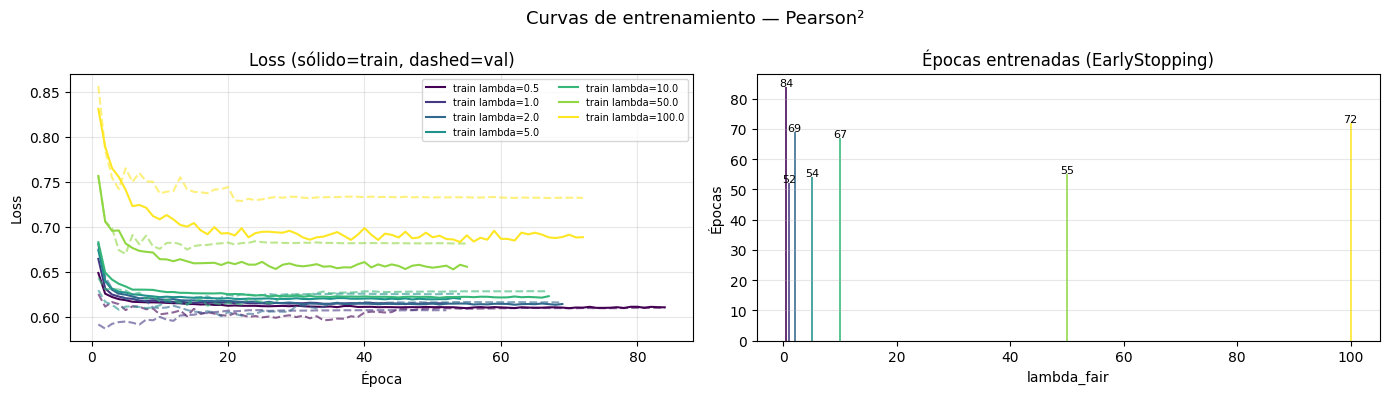

In [18]:
plot_training_curves(hist_pearson_sq, 'Pearson²')


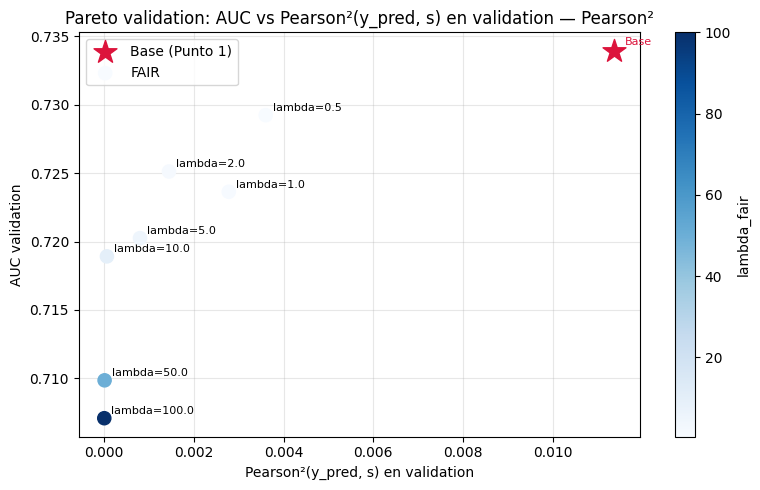

In [19]:
plot_pareto_sweep(df_pearson_sq, "Pearson²", "val_pearson_sq", "Pearson²(y_pred, s) en validation")


### Sweep — CKA RBF

Se entrena una segunda familia de modelos con la pérdida:

`BCE + λ·CKA_RBF(ŷ, s)`

Esta formulación utiliza una medida basada en kernel gaussiano para penalizar dependencia estadística entre las predicciones y la variable sensible. Se usa como métrica complementaria a Pearson², ya que ambas medidas no son directamente equivalentes en escala.


In [20]:
print("Iniciando sweep: CKA RBF")
df_cka_rbf, probas_cka_rbf, hist_cka_rbf, models_cka_rbf = run_fair_sweep(
    loss_class=FairLossCKARBF,
    loss_kwargs_fn=lambda lam: {"lambda_fair": lam, "gamma": 0.5},
    sweep_name="CKA RBF",
)
display(df_cka_rbf)


Iniciando sweep: CKA RBF
  [CKA RBF] lambda=0.5 ... val_auc=0.7256 test_auc=0.7281 val_Pearson²=0.0048 val_CKA_RBF=0.0057
  [CKA RBF] lambda=1.0 ... val_auc=0.7274 test_auc=0.7311 val_Pearson²=0.0027 val_CKA_RBF=0.0036
  [CKA RBF] lambda=2.0 ... val_auc=0.7203 test_auc=0.7241 val_Pearson²=0.0012 val_CKA_RBF=0.0019
  [CKA RBF] lambda=5.0 ... val_auc=0.7188 test_auc=0.7213 val_Pearson²=0.0004 val_CKA_RBF=0.0007
  [CKA RBF] lambda=10.0 ... val_auc=0.7198 test_auc=0.7247 val_Pearson²=0.0000 val_CKA_RBF=0.0002
  [CKA RBF] lambda=50.0 ... val_auc=0.7105 test_auc=0.7158 val_Pearson²=0.0000 val_CKA_RBF=0.0003
  [CKA RBF] lambda=100.0 ... val_auc=0.7082 test_auc=0.7133 val_Pearson²=0.0000 val_CKA_RBF=0.0001


,loss_type,lambda_fair,val_auc,val_accuracy,val_balanced_accuracy,val_recall_class_1,val_precision_class_1,val_f1_class_1,val_pearson_sq,val_cka_rbf,...,test_balanced_accuracy,test_recall_class_1,test_precision_class_1,test_f1_class_1,test_pearson_sq,test_cka_rbf,test_mean_pred_gender_0,test_mean_pred_gender_1,test_mean_pred_gap_abs,test_predicted_positive_rate_gap_abs
0,CKA RBF,0.5,0.725586,0.699335,0.666982,0.628399,0.157845,0.252312,0.004830,0.005687,...,0.667714,0.626989,0.158851,0.253481,0.005458,0.007929,0.437533,0.413893,0.023640,0.059709
1,CKA RBF,1.0,0.727419,0.689966,0.668086,0.641994,0.155659,0.250565,0.002712,0.003603,...,0.672054,0.647130,0.157926,0.253892,0.003362,0.004906,0.437472,0.416834,0.020637,0.049800
2,CKA RBF,2.0,0.720305,0.723806,0.662379,0.589124,0.163671,0.256172,0.001223,0.001933,...,0.661626,0.585700,0.163868,0.256087,0.001834,0.003119,0.419593,0.406186,0.013407,0.034214
3,CKA RBF,5.0,0.718752,0.678320,0.662900,0.644512,0.150810,0.244426,0.000436,0.000732,...,0.662274,0.641490,0.150919,0.244352,0.000832,0.001958,0.434928,0.425006,0.009922,0.029994
4,CKA RBF,10.0,0.719809,0.686165,0.661885,0.632931,0.152391,0.245640,0.000049,0.000240,...,0.666483,0.641490,0.154402,0.248896,0.000180,0.000638,0.434583,0.430080,0.004503,0.017632
5,CKA RBF,50.0,0.710502,0.636857,0.653209,0.672709,0.138885,0.230236,0.000044,0.000268,...,0.659744,0.682578,0.141698,0.234679,0.000210,0.000695,0.451829,0.447031,0.004798,0.011929
6,CKA RBF,100.0,0.708180,0.619439,0.652117,0.691088,0.135609,0.226728,0.000017,0.000148,...,0.658905,0.700302,0.138515,0.231283,0.000116,0.000425,0.442512,0.438656,0.003856,0.016213


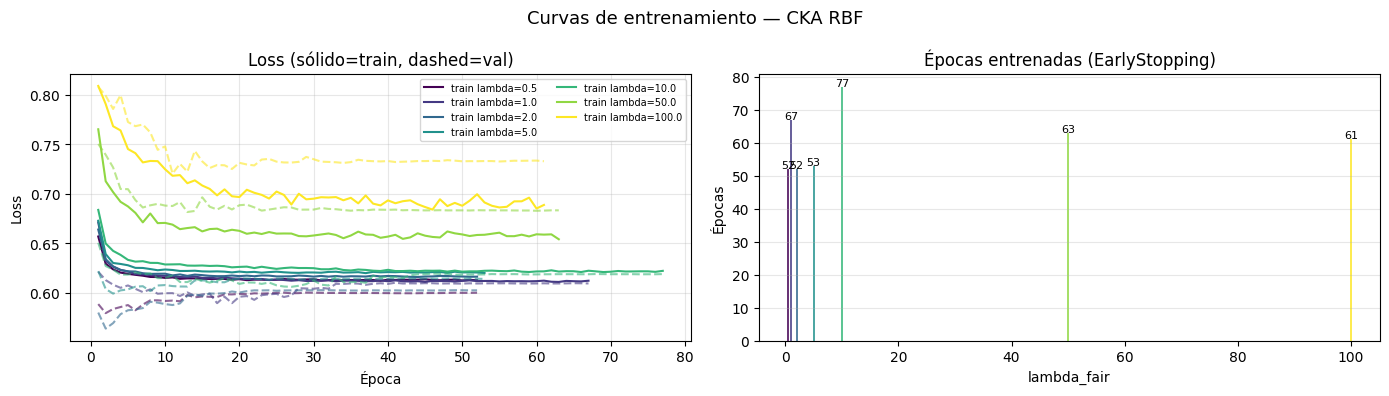

In [21]:
plot_training_curves(hist_cka_rbf, 'CKA RBF')


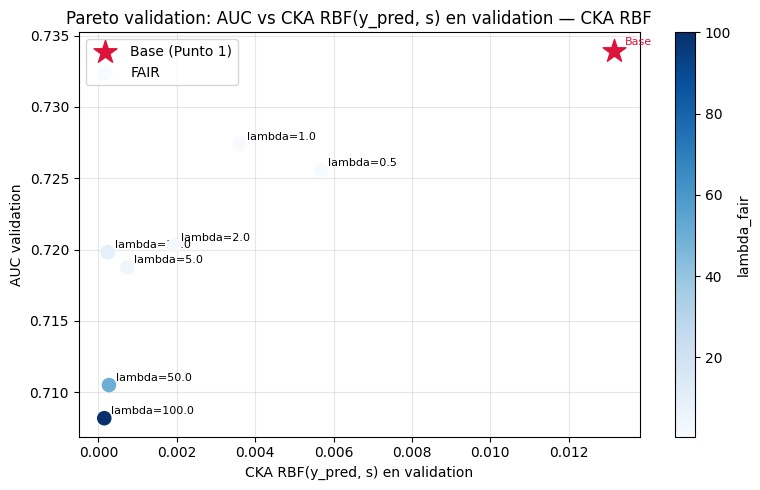

In [22]:
plot_pareto_sweep(df_cka_rbf, "CKA RBF", "val_cka_rbf", "CKA RBF(y_pred, s) en validation")


En esta ejecución, CKA RBF toma valores superiores a Pearson². Esto sugiere que la medida basada en kernel puede estar capturando dependencia adicional respecto a la medida lineal, aunque ambas métricas no son directamente equivalentes en escala.

Por ese motivo no se interpreta CKA como una versión numéricamente comparable de Pearson², sino como una auditoría complementaria. La selección del mejor modelo FAIR se realiza con validation, priorizando reducción de dependencia con una pérdida moderada de AUC respecto al modelo base.

## Exportación de artefactos del mejor modelo FAIR

Se guardan artefactos que resumen el mejor modelo FAIR seleccionado con validation. En esta sección no se usa test para seleccionar hiperparámetros: test se usa únicamente para reportar el rendimiento final del modelo elegido.

| Fichero | Contenido |
|---|---|
| `best_fair_proba_test.npy` | Probabilidades del mejor modelo FAIR sobre test |
| `best_fair_config.json` | Configuración de la loss ganadora y criterio de selección |
| `comparison_base_vs_fair.csv` | Tabla comparativa base vs mejor FAIR |
| `fair_group_gaps_base_vs_fair.csv` | Gaps por grupo sensible en test |

Resultados completos de sweeps FAIR guardados en: outputs/fair_results_all_sweeps.csv
Mejor modelo FAIR seleccionado con validation:
  loss_type  : CKA RBF
  lambda     : 10.0
  val AUC    : 0.7198  (base validation: 0.7339)
  val CKA RBF: 0.000240  (base validation: 0.013163)
  test AUC   : 0.7247
  test CKA   : 0.000638  (base test: 0.015178)
Probabilidades guardadas en: outputs/best_fair_proba_test.npy
Config guardada en: outputs/best_fair_config.json
{
  "selection_split": "validation",
  "selection_rule": "val_auc >= base_val_auc - 0.015; then minimize val_cka_rbf and val_pearson_sq",
  "loss_type": "CKA RBF",
  "loss_class": "FairLossCKARBF",
  "lambda_fair": 10.0,
  "gamma": 0.5,
  "validation_metrics": {
    "auc": 0.7198094214388068,
    "pearson_sq": 4.858275696633043e-05,
    "cka_rbf": 0.00024045412692272095
  },
  "test_metrics": {
    "auc": 0.724728188676841,
    "pearson_sq": 0.00018016137386120363,
    "cka_rbf": 0.0006375282655582148
  },
  "base_validation_metrics": 

,CODE_GENDER,n,target_rate,mean_pred_proba,predicted_positive_rate,auc,recall_class_1,precision_class_1
0,0,20958,0.101584,0.458167,0.404905,0.730849,0.702208,0.176173
1,1,40544,0.069949,0.417444,0.312623,0.734486,0.636812,0.142485


Auditoría por grupo del mejor modelo FAIR en test:


,CODE_GENDER,n,target_rate,mean_pred_proba,predicted_positive_rate,auc,recall_class_1,precision_class_1
0,0,20958,0.101584,0.434583,0.347027,0.728339,0.645373,0.188918
1,1,40544,0.069949,0.430080,0.329395,0.721736,0.638575,0.135605


Gaps por grupo guardados en: outputs/fair_group_gaps_base_vs_fair.csv


,model_name,mean_pred_gap_abs,predicted_positive_rate_gap_abs,target_rate_gap_abs
0,base_punto_1,0.040723,0.092282,0.031635
1,fair_CKA RBF_lambda_10.0,0.004503,0.017632,0.031635


Tabla comparativa guardada en: outputs/comparison_base_vs_fair.csv


,model_name,selection_split,loss_type,lambda_fair,test_auc,test_accuracy,test_balanced_accuracy,test_recall_class_1,test_precision_class_1,test_f1_class_1,test_pearson_sq,test_cka_rbf,test_mean_pred_gap_abs,test_predicted_positive_rate_gap_abs
0,base_punto_1,not_applicable,BCE,0.0,0.736928,0.682547,0.674477,0.664854,0.155995,0.252698,0.01236,0.015178,0.040723,0.092282
1,fair_CKA RBF_lambda_10.0,validation,CKA RBF,10.0,0.724728,0.687441,0.666483,0.641490,0.154402,0.248896,0.00018,0.000638,0.004503,0.017632


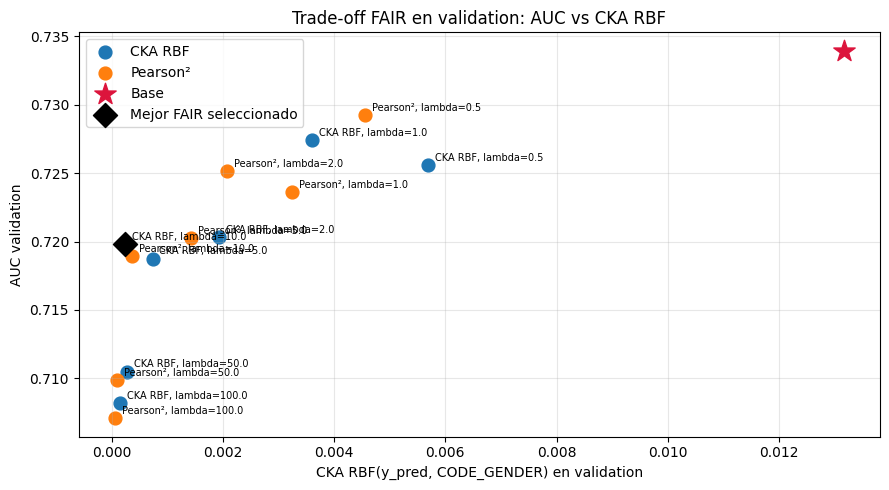

In [23]:
import json as _json

all_fair_results_df = pd.concat([df_pearson_sq, df_cka_rbf], ignore_index=True)
all_fair_results_path = OUTPUT_DIR / "fair_results_all_sweeps.csv"
all_fair_results_df.to_csv(all_fair_results_path, index=False)
print(f"Resultados completos de sweeps FAIR guardados en: {all_fair_results_path}")

# Selección metodológicamente limpia: se usa validation, nunca test.
auc_tolerance = 0.015
base_val_auc = base_metrics["val_auc"]
auc_floor = base_val_auc - auc_tolerance

candidate_df = all_fair_results_df[all_fair_results_df["val_auc"] >= auc_floor].copy()
if candidate_df.empty:
    print(
        "Ningún modelo FAIR queda dentro del margen de AUC en validation; "
        "se selecciona el de mayor AUC validation y menor dependencia como desempate."
    )
    best_fair_row = all_fair_results_df.sort_values(
        ["val_auc", "val_cka_rbf", "val_pearson_sq"],
        ascending=[False, True, True],
    ).iloc[0]
else:
    best_fair_row = candidate_df.sort_values(
        ["val_cka_rbf", "val_pearson_sq", "val_auc"],
        ascending=[True, True, False],
    ).iloc[0]

BEST_LOSS_TYPE = best_fair_row["loss_type"]
BEST_LAMBDA = float(best_fair_row["lambda_fair"])
BEST_SWEEP = "cka_rbf"

if BEST_LOSS_TYPE == "Pearson²":
    best_proba_val = probas_pearson_sq[BEST_LAMBDA]["validation"]
    best_proba = probas_pearson_sq[BEST_LAMBDA]["test"]
    best_fair_model = models_pearson_sq[BEST_LAMBDA]
else:
    best_proba_val = probas_cka_rbf[BEST_LAMBDA]["validation"]
    best_proba = probas_cka_rbf[BEST_LAMBDA]["test"]
    best_fair_model = models_cka_rbf[BEST_LAMBDA]

best_metrics_fair = best_fair_row.to_dict()

y_test_proba_best_fair = best_proba
print("Mejor modelo FAIR seleccionado con validation:")
print(f"  loss_type  : {BEST_LOSS_TYPE}")
print(f"  lambda     : {BEST_LAMBDA}")
print(f"  val AUC    : {best_metrics_fair['val_auc']:.4f}  (base validation: {base_metrics['val_auc']:.4f})")
print(f"  val CKA RBF: {best_metrics_fair['val_cka_rbf']:.6f}  (base validation: {base_metrics['val_cka_rbf']:.6f})")
print(f"  test AUC   : {best_metrics_fair['test_auc']:.4f}")
print(f"  test CKA   : {best_metrics_fair['test_cka_rbf']:.6f}  (base test: {base_metrics['test_cka_rbf']:.6f})")

# Guardar probabilidades del mejor modelo FAIR sobre test.
proba_path = OUTPUT_DIR / "best_fair_proba_test.npy"
np.save(proba_path, y_test_proba_best_fair)
print(f"Probabilidades guardadas en: {proba_path}")

best_fair_config = {
    "selection_split": "validation",
    "selection_rule": f"val_auc >= base_val_auc - {auc_tolerance}; then minimize val_cka_rbf and val_pearson_sq",
    "loss_type": BEST_LOSS_TYPE,
    "loss_class": "FairLossPearson" if BEST_LOSS_TYPE == "Pearson²" else "FairLossCKARBF",
    "lambda_fair": BEST_LAMBDA,
    "gamma": 0.5 if BEST_LOSS_TYPE == "CKA RBF" else None,
    "validation_metrics": {
        "auc": best_metrics_fair["val_auc"],
        "pearson_sq": best_metrics_fair["val_pearson_sq"],
        "cka_rbf": best_metrics_fair["val_cka_rbf"],
    },
    "test_metrics": {
        "auc": best_metrics_fair["test_auc"],
        "pearson_sq": best_metrics_fair["test_pearson_sq"],
        "cka_rbf": best_metrics_fair["test_cka_rbf"],
    },
    "base_validation_metrics": {
        "auc": base_metrics["val_auc"],
        "pearson_sq": base_metrics["val_pearson_sq"],
        "cka_rbf": base_metrics["val_cka_rbf"],
    },
    "base_test_metrics": {
        "auc": base_metrics["test_auc"],
        "pearson_sq": base_metrics["test_pearson_sq"],
        "cka_rbf": base_metrics["test_cka_rbf"],
    },
}

config_path = OUTPUT_DIR / "best_fair_config.json"
with open(config_path, "w", encoding="utf-8") as fh:
    _json.dump(best_fair_config, fh, indent=2)
print(f"Config guardada en: {config_path}")
print(_json.dumps(best_fair_config, indent=2))


def fairness_group_report(y_true, y_proba, s, threshold=0.5):
    """Reporte por grupo sensible CODE_GENDER y gaps absolutos entre grupos."""
    y_true = np.asarray(y_true).reshape(-1).astype(int)
    y_proba = np.asarray(y_proba).reshape(-1)
    s = np.asarray(s).reshape(-1)
    y_pred = (y_proba >= threshold).astype(int)

    rows = []
    for group_value in sorted(np.unique(s)):
        mask = s == group_value
        group_y_true = y_true[mask]
        group_y_proba = y_proba[mask]
        group_y_pred = y_pred[mask]

        try:
            group_auc = roc_auc_score(group_y_true, group_y_proba)
        except ValueError:
            group_auc = np.nan

        rows.append(
            {
                "CODE_GENDER": int(group_value),
                "n": int(mask.sum()),
                "target_rate": float(np.mean(group_y_true)),
                "mean_pred_proba": float(np.mean(group_y_proba)),
                "predicted_positive_rate": float(np.mean(group_y_pred)),
                "auc": group_auc,
                "recall_class_1": recall_score(group_y_true, group_y_pred, zero_division=0),
                "precision_class_1": precision_score(group_y_true, group_y_pred, zero_division=0),
            }
        )

    report = pd.DataFrame(rows)

    if len(report) == 2:
        gaps = {
            "mean_pred_gap_abs": float(abs(report.loc[0, "mean_pred_proba"] - report.loc[1, "mean_pred_proba"])),
            "predicted_positive_rate_gap_abs": float(abs(report.loc[0, "predicted_positive_rate"] - report.loc[1, "predicted_positive_rate"])),
            "target_rate_gap_abs": float(abs(report.loc[0, "target_rate"] - report.loc[1, "target_rate"])),
        }
    else:
        gaps = {
            "mean_pred_gap_abs": np.nan,
            "predicted_positive_rate_gap_abs": np.nan,
            "target_rate_gap_abs": np.nan,
        }

    return report, gaps


base_group_report_test, base_group_gaps_test = fairness_group_report(
    y_test_np, y_test_proba_base, s_test_np
)
best_fair_group_report_test, best_fair_group_gaps_test = fairness_group_report(
    y_test_np, y_test_proba_best_fair, s_test_np
)

print("Auditoría por grupo del modelo base en test:")
display(base_group_report_test)
print("Auditoría por grupo del mejor modelo FAIR en test:")
display(best_fair_group_report_test)

fair_group_gaps_df = pd.DataFrame(
    [
        {"model_name": "base_punto_1", **base_group_gaps_test},
        {"model_name": f"fair_{BEST_LOSS_TYPE}_lambda_{BEST_LAMBDA}", **best_fair_group_gaps_test},
    ]
)
gaps_path = OUTPUT_DIR / "fair_group_gaps_base_vs_fair.csv"
fair_group_gaps_df.to_csv(gaps_path, index=False)
print(f"Gaps por grupo guardados en: {gaps_path}")
display(fair_group_gaps_df)

comparison_df = pd.DataFrame(
    [
        {
            "model_name": "base_punto_1",
            "selection_split": "not_applicable",
            "loss_type": "BCE",
            "lambda_fair": 0.0,
            "test_auc": base_metrics["test_auc"],
            "test_accuracy": base_metrics["test_accuracy"],
            "test_balanced_accuracy": base_metrics["test_balanced_accuracy"],
            "test_recall_class_1": base_metrics["test_recall_class_1"],
            "test_precision_class_1": base_metrics["test_precision_class_1"],
            "test_f1_class_1": base_metrics["test_f1_class_1"],
            "test_pearson_sq": base_metrics["test_pearson_sq"],
            "test_cka_rbf": base_metrics["test_cka_rbf"],
            "test_mean_pred_gap_abs": base_group_gaps_test["mean_pred_gap_abs"],
            "test_predicted_positive_rate_gap_abs": base_group_gaps_test["predicted_positive_rate_gap_abs"],
        },
        {
            "model_name": f"fair_{BEST_LOSS_TYPE}_lambda_{BEST_LAMBDA}",
            "selection_split": "validation",
            "loss_type": BEST_LOSS_TYPE,
            "lambda_fair": BEST_LAMBDA,
            "test_auc": best_metrics_fair["test_auc"],
            "test_accuracy": best_metrics_fair["test_accuracy"],
            "test_balanced_accuracy": best_metrics_fair["test_balanced_accuracy"],
            "test_recall_class_1": best_metrics_fair["test_recall_class_1"],
            "test_precision_class_1": best_metrics_fair["test_precision_class_1"],
            "test_f1_class_1": best_metrics_fair["test_f1_class_1"],
            "test_pearson_sq": best_metrics_fair["test_pearson_sq"],
            "test_cka_rbf": best_metrics_fair["test_cka_rbf"],
            "test_mean_pred_gap_abs": best_fair_group_gaps_test["mean_pred_gap_abs"],
            "test_predicted_positive_rate_gap_abs": best_fair_group_gaps_test["predicted_positive_rate_gap_abs"],
        },
    ]
)

comp_path = OUTPUT_DIR / "comparison_base_vs_fair.csv"
comparison_df.to_csv(comp_path, index=False)
print(f"Tabla comparativa guardada en: {comp_path}")
display(comparison_df)

# Gráfico global de trade-off en validation, destacando el mejor modelo FAIR.
fig, ax = plt.subplots(figsize=(9, 5))
for loss_type, loss_df in all_fair_results_df.groupby("loss_type"):
    ax.scatter(loss_df["val_cka_rbf"], loss_df["val_auc"], s=85, label=loss_type)
    for _, row in loss_df.iterrows():
        ax.annotate(
            f"{loss_type}, lambda={row['lambda_fair']}",
            (row["val_cka_rbf"], row["val_auc"]),
            xytext=(5, 3),
            textcoords="offset points",
            fontsize=7,
        )
ax.scatter(
    [base_metrics["val_cka_rbf"]],
    [base_metrics["val_auc"]],
    marker="*",
    s=260,
    color="crimson",
    label="Base",
    zorder=5,
)
ax.scatter(
    [best_fair_row["val_cka_rbf"]],
    [best_fair_row["val_auc"]],
    marker="D",
    s=150,
    color="black",
    label="Mejor FAIR seleccionado",
    zorder=6,
)
ax.set_title("Trade-off FAIR en validation: AUC vs CKA RBF")
ax.set_xlabel("CKA RBF(y_pred, CODE_GENDER) en validation")
ax.set_ylabel("AUC validation")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


## Comentarios y conclusiones provisionales de la práctica

En esta versión del notebook se han desarrollado los dos primeros bloques de la práctica `B4-T1: Diseño de Redes Confiables`.

En primer lugar, se ha construido una arquitectura customizada para clasificación binaria de riesgo de crédito sobre el dataset `Home Credit Default Risk`. La red utiliza dos entradas: una rama principal con variables numéricas imputadas y escaladas, y una rama financiera en bruto que conserva los importes originales de ingresos, crédito y anualidad. Sobre esta segunda rama se ha implementado la capa customizada `DebtBurdenLayer`, que calcula internamente ratios de endeudamiento y aplica una saturación suave mediante `tanh`. Esta capa introduce conocimiento financiero explícito dentro de la arquitectura y evita que ratios extremos dominen el entrenamiento.

El modelo base obtiene un AUC test de 0.7369 y una balanced accuracy de 0.6745. Dado que la variable objetivo está fuertemente desbalanceada, la accuracy no debe interpretarse de forma aislada. Por ese motivo se reportan también recall, precision y F1 de la clase minoritaria.

En segundo lugar, se ha añadido el bloque de aprendizaje justo mediante funciones de coste customizadas. La variable `CODE_GENDER` no se utiliza como entrada predictiva del modelo, pero se conserva como variable sensible para auditar y penalizar la dependencia estadística entre las predicciones del modelo y el género. Se han probado dos formulaciones de FAIR Loss: una basada en la correlación de Pearson al cuadrado y otra basada en CKA con kernel RBF.

Los resultados muestran el trade-off esperado entre rendimiento predictivo y reducción de dependencia. El modelo base presenta un AUC test de 0.7369, Pearson² de 0.01236 y CKA RBF de 0.01518. El mejor modelo FAIR seleccionado con validation es el modelo con pérdida `CKA RBF` y `λ = 10.0`, que obtiene un AUC test de 0.7247, Pearson² de 0.00018 y CKA RBF de 0.00064.

Esto supone una reducción aproximada del 98.5 % en Pearson² y del 95.8 % en CKA RBF, con una pérdida de AUC de unos 0.012 puntos. También se reduce el gap de probabilidad media predicha por género, de 0.0407 a 0.0045, y el gap de tasa de predicción positiva, de 0.0923 a 0.0176.

El mejor modelo FAIR se selecciona utilizando el conjunto de validación, no el conjunto de test. El test se reserva para reportar el rendimiento final del modelo elegido. Esta separación evita utilizar el test como criterio de decisión y hace que la comparación sea metodológicamente más defendible.

Estos resultados no prueban que el modelo sea completamente justo ni eliminan la necesidad de una auditoría más amplia. La reducción de dependencia respecto a `CODE_GENDER` debe interpretarse como una mejora parcial bajo las métricas utilizadas. Por ese motivo se complementan Pearson² y CKA con métricas por grupo, como la probabilidad media predicha por género, la tasa de predicción positiva, el recall por grupo y los gaps entre grupos.

Como conclusión provisional, el notebook ya contiene una arquitectura customizada funcional y una primera estrategia de aprendizaje justo. Las siguientes fases deberán integrar la optimización automática de hiperparámetros con Keras Tuner y la estimación de incertidumbre predictiva, manteniendo la comparación entre rendimiento, justicia e incertidumbre como eje central de la práctica.


In [ ]:
'''
!zip -r /content/outputs.zip /content/outputs

from google.colab import files
files.download('/content/outputs.zip')
'''


  adding: content/outputs/ (stored 0%)
  adding: content/outputs/metrics_punto1_custom_layer.csv (deflated 34%)
  adding: content/outputs/training_history_punto1_custom_layer.csv (deflated 59%)
  adding: content/outputs/fair_results_all_sweeps.csv (deflated 52%)
  adding: content/outputs/comparison_base_vs_fair.csv (deflated 42%)
  adding: content/outputs/best_fair_config.json (deflated 54%)
  adding: content/outputs/ext_source_missingness_summary.csv (deflated 27%)
  adding: content/outputs/fair_group_gaps_base_vs_fair.csv (deflated 33%)
  adding: content/outputs/best_fair_proba_test.npy (deflated 12%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>